In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "Hn kya hua kya karna hai"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='b34a1150-399b-4de2-a5b7-a402180187bc'),
  AIMessage(content='Hn kya hua kya karna hai', additional_kwargs={}, response_metadata={}, id='1f6333be-36fd-44dc-81cb-7202c2d01797', tool_calls=[], invalid_tool_calls=[])]}

In [2]:
pip install -U langgraph

In [3]:
from langgraph.graph import StateGraph,END
from typing import TypedDict
from IPython.display import Image,display

In [4]:
class Mystate(TypedDict):
  message:str

def start_node(state:Mystate)->Mystate:
  print('Start node recieved:',state['message'])
  # process or pass the message to the end node
  return {'message':state['message']+"->processed by start"}

# define the end node
def end_node(state:Mystate)->Mystate:
  print('End node recieved:',state['message'])
  return state

# build the graph
builder=StateGraph(Mystate)

In [5]:
builder

In [6]:
# Add nodes
builder.add_node('start',start_node)
builder.add_node('end',end_node)


In [7]:
# define the flow
builder.set_entry_point('start')
builder.add_edge('start','end')
builder.add_edge('end',END) # END is a special marker for graph comletion

In [8]:
# compile the graph
graph=builder.compile()



In [9]:
# run the graph
result=graph.invoke({'message':'what is langchain vs langgraph'})
print('Final result:',result['message'])

Start node recieved: what is langchain vs langgraph
End node recieved: what is langchain vs langgraph->processed by start
Final result: what is langchain vs langgraph->processed by start


In [10]:
# !pip install langgraph langsmith

In [11]:
# !pip install langchain_groq langchain_community

In [12]:
grop_api_key=os.getenv('GROQ_API_KEY')
langsmith=os.getenv('LANGSMITH_API_KEY')

In [13]:
import os
os.environ['LANGSMITH_TRACING_V2']='true'

In [14]:
from langchain_groq import ChatGroq

In [30]:
llm=ChatGroq(groq_api_key=grop_api_key,model='llama-3.3-70b-versatile')
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7c3d2ad97b90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7c3d2adb4230>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [31]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [32]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [33]:
graph_builder

In [34]:
def chatbot(state:State):
  return {'messages':llm.invoke(state['messages'])}

In [35]:
graph_builder.add_node('chatbot',chatbot)

In [36]:
graph_builder

In [37]:
graph_builder.add_edge(START,'chatbot')
graph_builder.add_edge('chatbot',END)

In [38]:
graph=graph_builder.compile()

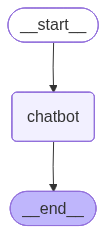

In [39]:
graph

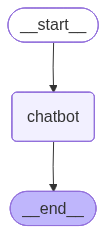

In [40]:
from IPython.display import Image ,display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
  pass

In [42]:

while True:
  user_input=input('User:')
  if user_input.lower() in ['quit','q']:
    print('Good Bye')
    break

  for event in graph.stream({'messages':('user',user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value['messages'].content)

User:hi
dict_values([{'messages': AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.044858655, 'completion_tokens_details': None, 'prompt_time': 0.001955964, 'prompt_tokens_details': None, 'queue_time': 0.024128435, 'total_time': 0.046814619}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4f81-1364-7360-b2c1-ed026884dabc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})}])
content="It's nice to meet you. Is there something I can help you with or would you like to chat?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 